# Lab 2 - Automatizacion: cada job cuenta su historia

**Modalidad:** guiado - **Duracion:** ~12 min
**Dataset:** automation_runs.csv

## El caso de negocio

El equipo DevOps nos pasa una lista de 8 jobs automatizados que se ejecutan a diario. El director pregunta:

> «¿Cuanto tiempo perdemos al año por jobs que fallan o se demoran? ¿Cual deberiamos reescribir primero?»

## Entregable
Tabla por job con: runs, success_rate, retries, MTTR, y decision asociada (mantener, optimizar, reescribir).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
runs = pd.read_csv(DATA / 'automation_runs.csv', parse_dates=['started_at'])
runs.head()

,run_id,job_name,started_at,duration_sec,status,retries,triggered_by,service
0,R-00001,purge_cache,2026-08-01 09:34:00,4.0,success,0,schedule,billing-worker
1,R-00002,snapshot_rds,2026-08-30 01:18:00,114.0,success,0,schedule,billing-worker
2,R-00003,db_vacuum,2026-08-08 00:41:00,186.0,success,0,manual,search-api
3,R-00004,restart_pod,2026-08-10 07:54:00,23.0,success,0,schedule,notifications
4,R-00005,purge_cache,2026-09-08 20:23:00,18.0,success,0,schedule,auth-service


## 1. Limpieza - que datos faltantes / imposibles hay

**Que decidimos:** si un job tiene duration_sec = -1, no es un job lento, es bug del exporter. Lo dropeamos antes de calcular MTTR.

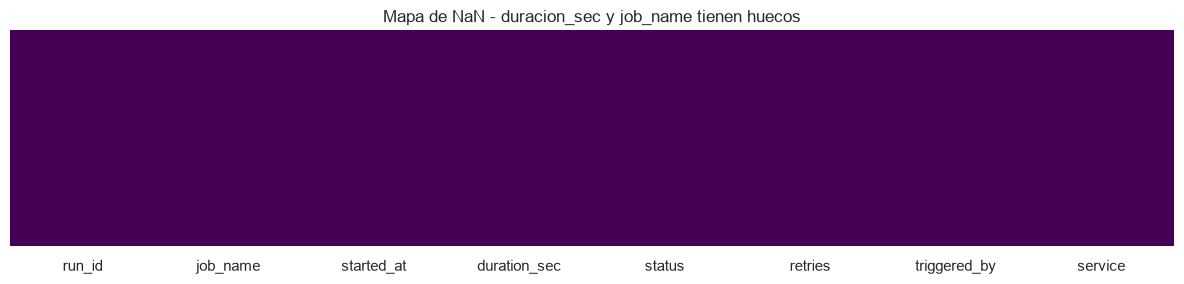

In [2]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(runs.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de NaN - duracion_sec y job_name tienen huecos')
plt.tight_layout()
plt.savefig('../html/lab2_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

In [3]:
bad = (runs['duration_sec'] < 0) | (runs['duration_sec'] > 86400)
print(f'duraciones imposibles: {bad.sum()}')
runs = runs.loc[~bad].copy()
med_by_job = runs.groupby('job_name')['duration_sec'].transform('median')
runs['duration_sec'] = runs['duration_sec'].fillna(med_by_job)
runs['job_name'] = runs['job_name'].fillna(runs['job_name'].mode().iloc[0])
print('shape limpio:', runs.shape)

duraciones imposibles: 16
shape limpio: (1484, 8)


## 2. Boxplot por job (log) - la distribucion natural

**Que decidimos:** la mediana dice cual es el caso tipico; la caja dice el 50% comun; los puntos arriba del bigote son outliers reales (jobs lentos).

**Por que log:** porque purge_cache corre en 2s y db_vacuum en 2min. Sin log, los pequenos se aplastan contra cero.

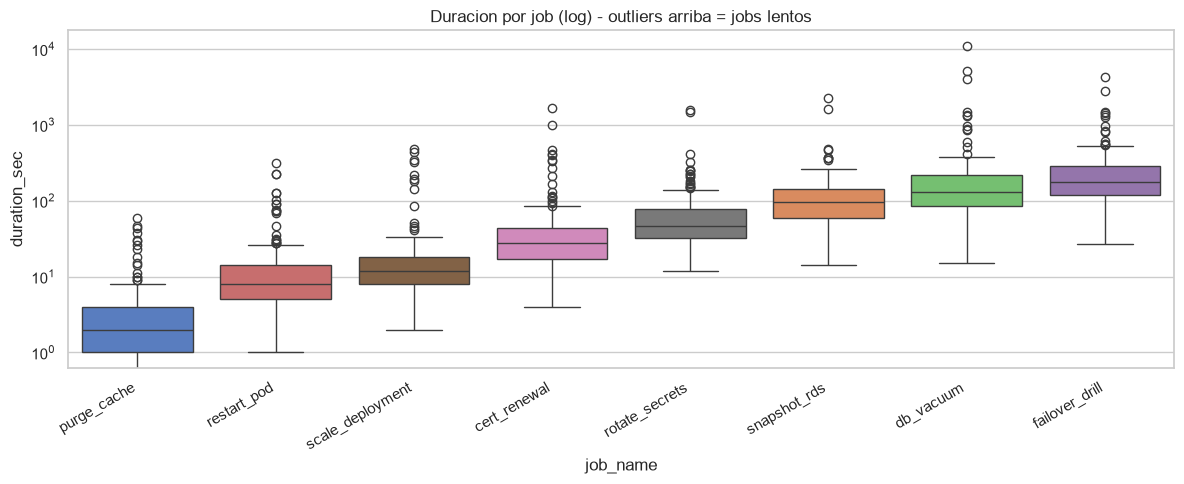

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
order = runs.groupby('job_name')['duration_sec'].median().sort_values().index
sns.boxplot(data=runs, x='job_name', y='duration_sec', order=order, hue='job_name', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Duracion por job (log) - outliers arriba = jobs lentos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../html/lab2_fig2_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. ¿Cuanto tiempo del equipo se va en fallos?

**Que decidimos:** el MTTR (mediana de duracion en fallos) multiplicado por numero de fallos al año = horas-hombre perdidas. Si supera X, reescribimos.

In [5]:
by_job = runs.groupby('job_name').agg(
    runs=('run_id', 'count'),
    success_rate=('status', lambda s: (s == 'success').mean()),
    avg_retries=('retries', 'mean'),
    p50_dur=('duration_sec', lambda s: s.quantile(0.5)),
    p95_dur=('duration_sec', lambda s: s.quantile(0.95)),
    failure_rate=('status', lambda s: (s != 'success').mean()),
)
failed = runs[runs['status'].isin(['failed', 'timeout'])]
by_job['mttr_sec'] = failed.groupby('job_name')['duration_sec'].median()
by_job = by_job.fillna(0).round(2)
by_job.sort_values('success_rate')

,runs,success_rate,avg_retries,p50_dur,p95_dur,failure_rate,mttr_sec
job_name,,,,,,,
failover_drill,191,0.77,0.47,174.00,582.50,0.23,189.5
db_vacuum,187,0.78,0.43,131.00,562.40,0.22,141.5
snapshot_rds,175,0.88,0.22,96.00,260.10,0.12,112.0
rotate_secrets,179,0.91,0.17,47.00,210.40,0.09,63.5
restart_pod,181,0.92,0.15,8.00,73.00,0.08,11.0
cert_renewal,194,0.93,0.15,27.75,143.20,0.07,29.0
scale_deployment,191,0.93,0.12,12.00,48.50,0.07,16.5
purge_cache,186,0.95,0.11,2.00,14.75,0.05,4.5


In [6]:
by_job['failures_per_year'] = (by_job['failure_rate'] * by_job['runs'] * 365 / 30).round(0)
by_job['hours_lost_per_year'] = (by_job['failures_per_year'] * by_job['mttr_sec'] / 3600).round(1)
by_job[['runs', 'success_rate', 'mttr_sec', 'failures_per_year', 'hours_lost_per_year']].sort_values('hours_lost_per_year', ascending=False)

,runs,success_rate,mttr_sec,failures_per_year,hours_lost_per_year
job_name,,,,,
failover_drill,191,0.77,189.5,534.0,28.1
db_vacuum,187,0.78,141.5,501.0,19.7
snapshot_rds,175,0.88,112.0,256.0,8.0
rotate_secrets,179,0.91,63.5,196.0,3.5
cert_renewal,194,0.93,29.0,165.0,1.3
scale_deployment,191,0.93,16.5,163.0,0.7
restart_pod,181,0.92,11.0,176.0,0.5
purge_cache,186,0.95,4.5,113.0,0.1


## 4. Visualizacion - que job duele mas al equipo

**Que decidimos:** la barra de horas perdidas es nuestra recomendacion de prioridad para reescribir.

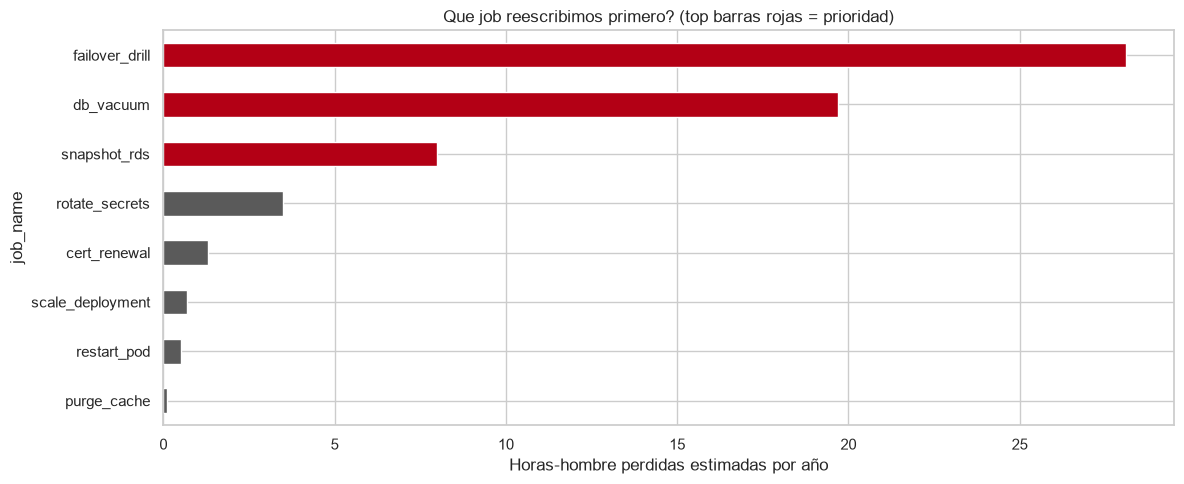

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
top_loss = by_job.sort_values('hours_lost_per_year', ascending=True)
colors = ['#b30015' if x > 5 else '#5a5a5a' for x in top_loss['hours_lost_per_year']]
top_loss['hours_lost_per_year'].plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Horas-hombre perdidas estimadas por año')
ax.set_title('Que job reescribimos primero? (top barras rojas = prioridad)')
plt.tight_layout()
plt.savefig('../html/lab2_fig3_hours_lost.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. MTTR vs tasa de fallo - que reescribimos

**Que decidimos:** un job con **baja tasa de fallo + alto MTTR** = reescribir (cuando falla, dura demasiado). **Alta tasa + bajo MTTR** = optimizar (falla mucho pero rapido, posiblemente script mal diseñado).

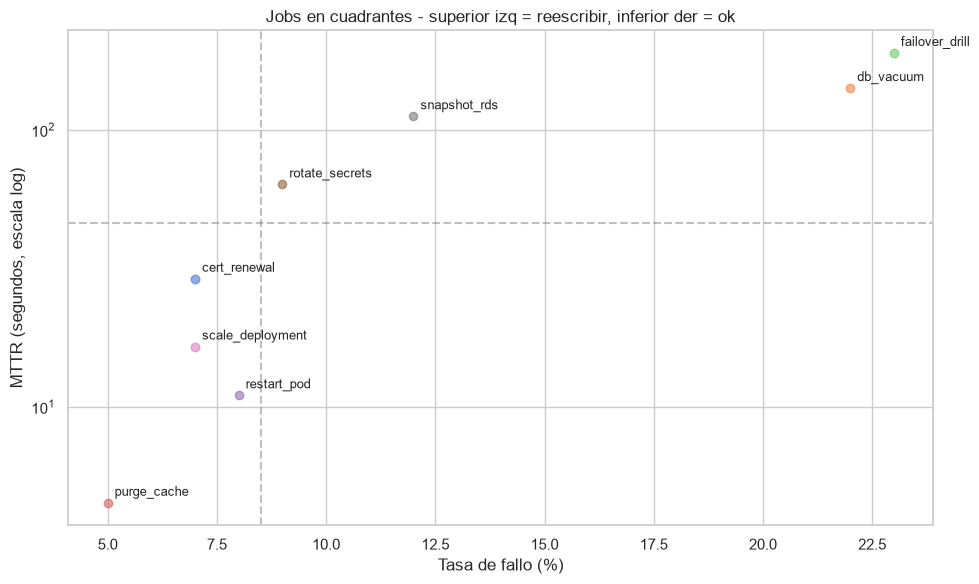

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in by_job.iterrows():
    ax.scatter(row['failure_rate'] * 100, row['mttr_sec'], s=row['runs']/5, alpha=0.6)
    ax.annotate(row.name, (row['failure_rate'] * 100, row['mttr_sec']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(y=by_job['mttr_sec'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axvline(x=by_job['failure_rate'].median() * 100, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Tasa de fallo (%)')
ax.set_ylabel('MTTR (segundos, escala log)')
ax.set_yscale('log')
ax.set_title('Jobs en cuadrantes - superior izq = reescribir, inferior der = ok')
plt.tight_layout()
plt.savefig('../html/lab2_fig4_quadrant.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Tu decision como SRE

- ¿Cual job es el #1 candidato a reescribir? (alto MTTR + baja tasa de fallo)
- ¿Cual job es el #1 candidato a optimizar? (alto fallo + bajo MTTR)
- ¿Cual job podrias dar de baja por no usarse?

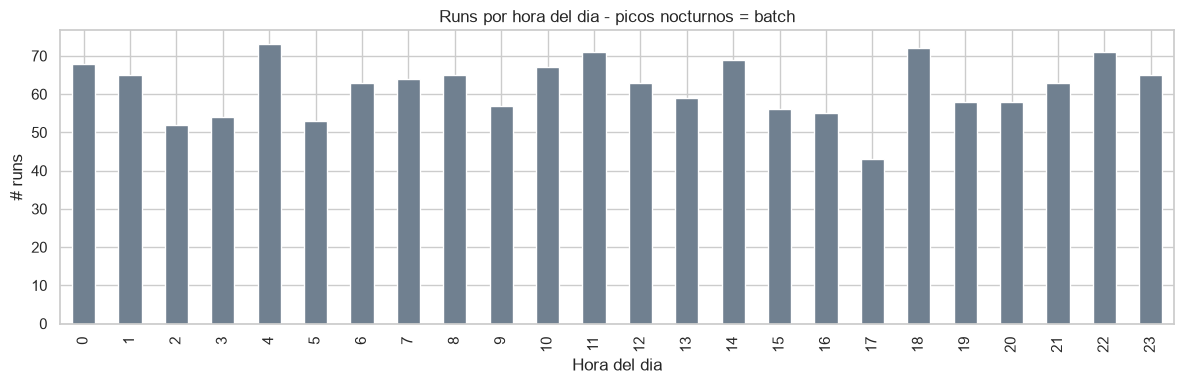

In [9]:
runs['hour'] = runs['started_at'].dt.hour
fig, ax = plt.subplots(figsize=(12, 4))
runs.groupby('hour').size().plot(kind='bar', color='slategray', ax=ax)
ax.set_title('Runs por hora del dia - picos nocturnos = batch')
ax.set_xlabel('Hora del dia')
ax.set_ylabel('# runs')
plt.tight_layout()
plt.savefig('../html/lab2_fig5_hourly.png', dpi=110, bbox_inches='tight')
plt.show()